DEVICE: cuda

Loading MNIST into memory...
MNIST: torch.Size([60000, 784]) torch.Size([60000, 10])

Creating parameter regions...
Train regions: 16
Test regions: 16

PRECOMPUTING REAL GRADIENTS

Dataset size: 50
region 01/16 | 0.00s
region 02/16 | 0.00s
region 03/16 | 0.00s
region 04/16 | 0.00s
region 05/16 | 0.00s
region 06/16 | 0.00s
region 07/16 | 0.00s
region 08/16 | 0.00s
region 09/16 | 0.00s
region 10/16 | 0.00s
region 11/16 | 0.00s
region 12/16 | 0.00s
region 13/16 | 0.00s
region 14/16 | 0.00s
region 15/16 | 0.00s
region 16/16 | 0.00s

Dataset size: 500
region 01/16 | 0.00s
region 02/16 | 0.00s
region 03/16 | 0.00s
region 04/16 | 0.00s
region 05/16 | 0.00s
region 06/16 | 0.00s
region 07/16 | 0.00s
region 08/16 | 0.00s
region 09/16 | 0.00s
region 10/16 | 0.00s
region 11/16 | 0.00s
region 12/16 | 0.00s
region 13/16 | 0.00s
region 14/16 | 0.00s
region 15/16 | 0.00s
region 16/16 | 0.00s

Dataset size: full
region 01/16 | 0.11s
region 02/16 | 0.10s
region 03/16 | 0.11s
region 04/16 |

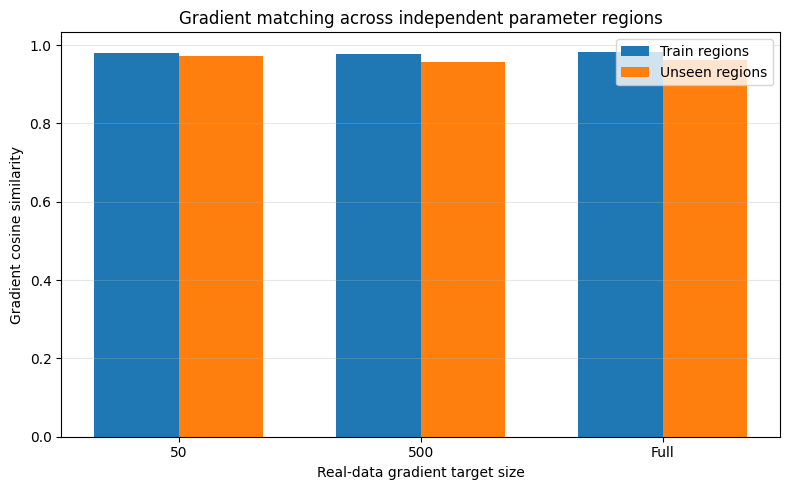

/tmp/ipykernel_512/3300956158.py:1220: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


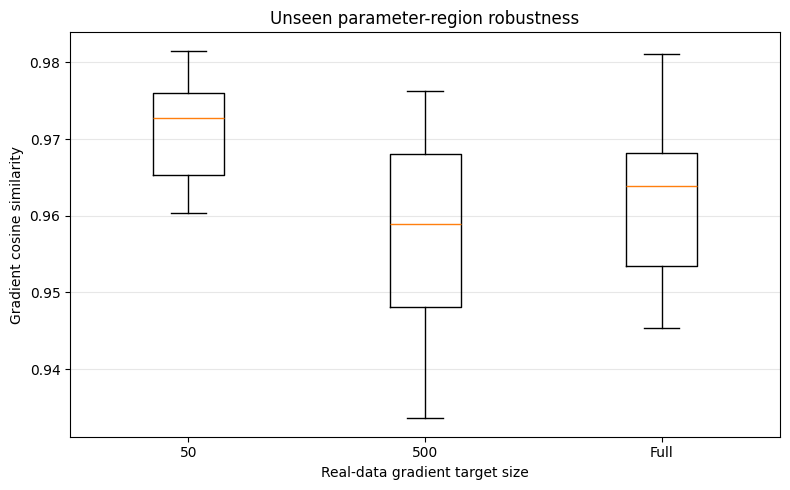

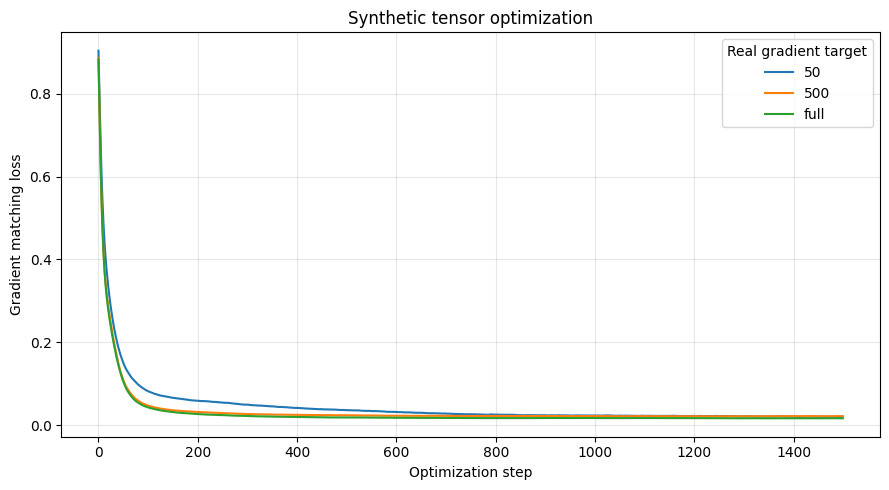


Results saved to: ./gm_results


In [3]:
# ============================================================
# MNIST Multi-Region Gradient Field Experiment
#
# Compare:
#
#   B = 50
#   B = 500
#   B = FULL MNIST TRAIN SET
#
# Training:
#
#   16 completely independent parameter regions
#
# Evaluation:
#
#   16 completely unseen parameter regions
#
# Metric:
#
#   Gradient cosine similarity
#
# ============================================================
import os
import random
import time
import json

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset


# ============================================================
# CONFIG
# ============================================================

SEED = 42

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)


# ------------------------------------------------------------
# Dataset sizes
# ------------------------------------------------------------

REAL_SIZES = {
    50: 50,
    500: 500,
    "full": 60000,
}


# ------------------------------------------------------------
# Synthetic dataset
# ------------------------------------------------------------

NUM_SYNTH = 50


# ------------------------------------------------------------
# Network
# ------------------------------------------------------------

HIDDEN = 128


# ------------------------------------------------------------
# Parameter regions
# ------------------------------------------------------------

NUM_TRAIN_REGIONS = 16
NUM_TEST_REGIONS = 16


# ------------------------------------------------------------
# Synthetic optimization
# ------------------------------------------------------------

STEPS = 1500
LR = 0.05

PRINT_EVERY = 50


# ------------------------------------------------------------
# Full gradient accumulation
# ------------------------------------------------------------

FULL_BATCH = 500


# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

SAVE_DIR = "./gm_results"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)


# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


set_seed(SEED)


# ============================================================
# Model
# ============================================================

class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(
            784,
            HIDDEN
        )

        self.fc2 = nn.Linear(
            HIDDEN,
            10
        )

        self.reset_parameters()


    def reset_parameters(self):

        nn.init.kaiming_normal_(
            self.fc1.weight,
            nonlinearity="relu"
        )

        nn.init.zeros_(
            self.fc1.bias
        )

        nn.init.kaiming_normal_(
            self.fc2.weight
        )

        nn.init.zeros_(
            self.fc2.bias
        )


    def forward(self, x):

        x = F.relu(
            self.fc1(x)
        )

        return self.fc2(x)


# ============================================================
# Soft-label cross entropy
# ============================================================

def soft_cross_entropy(
    logits,
    targets
):

    log_probs = F.log_softmax(
        logits,
        dim=1
    )

    return -(
        targets * log_probs
    ).sum(
        dim=1
    ).mean()


# ============================================================
# Functional forward
# ============================================================

def functional_forward(
    x,
    params
):

    w1, b1, w2, b2 = params

    h = F.linear(
        x,
        w1,
        b1
    )

    h = F.relu(h)

    logits = F.linear(
        h,
        w2,
        b2
    )

    return logits


# ============================================================
# Model -> detached parameter tuple
# ============================================================

def extract_parameters(
    model
):

    return tuple(
        p.detach().clone()
        for p in model.parameters()
    )


# ============================================================
# Create completely independent parameter region
# ============================================================

def create_region():

    model = MLP().to(
        DEVICE
    )

    params = tuple(
        p.detach().clone().requires_grad_(True)
        for p in model.parameters()
    )

    return params


# ============================================================
# Create regions
# ============================================================

def create_regions(
    num_regions
):

    regions = []

    for i in range(
        num_regions
    ):

        regions.append(
            create_region()
        )

    return regions


# ============================================================
# Gradient calculation
# ============================================================

def compute_gradient(
    params,
    x,
    y,
    create_graph=False
):

    logits = functional_forward(
        x,
        params
    )

    loss = soft_cross_entropy(
        logits,
        y
    )

    grads = torch.autograd.grad(
        loss,
        params,
        create_graph=create_graph,
        retain_graph=create_graph
    )

    return torch.cat([
        g.reshape(-1)
        for g in grads
    ])


# ============================================================
# Gradient cosine
# ============================================================

def gradient_cosine(
    a,
    b
):

    a = a / (
        a.norm() + 1e-12
    )

    b = b / (
        b.norm() + 1e-12
    )

    return torch.sum(
        a * b
    )


# ============================================================
# Gradient matching loss
# ============================================================

def gradient_matching_loss(
    synthetic_gradient,
    real_gradient
):

    return (
        1.0
        -
        gradient_cosine(
            synthetic_gradient,
            real_gradient
        )
    )


# ============================================================
# Load MNIST
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])


train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# ============================================================
# Convert complete MNIST to tensors
#
# This makes subset/full experiments reproducible.
# ============================================================

print()
print("Loading MNIST into memory...")


all_x = torch.stack([
    train_dataset[i][0]
    for i in range(
        len(train_dataset)
    )
])


all_y = torch.tensor([
    train_dataset[i][1]
    for i in range(
        len(train_dataset)
    )
])


all_x = all_x.reshape(
    len(all_x),
    -1
).float()


all_y = F.one_hot(
    all_y,
    num_classes=10
).float()


print(
    "MNIST:",
    all_x.shape,
    all_y.shape
)


# ============================================================
# Fixed subsets
#
# IMPORTANT:
# 50 is contained in 500.
# 500 is contained in FULL.
#
# This gives a nested comparison.
# ============================================================

generator = torch.Generator()

generator.manual_seed(
    SEED
)


permutation = torch.randperm(
    len(all_x),
    generator=generator
)


idx_50 = permutation[:50]

idx_500 = permutation[:500]

idx_full = permutation


datasets_for_experiment = {

    50: (
        all_x[idx_50].to(DEVICE),
        all_y[idx_50].to(DEVICE)
    ),

    500: (
        all_x[idx_500].to(DEVICE),
        all_y[idx_500].to(DEVICE)
    ),

    "full": (
        all_x.to(DEVICE),
        all_y.to(DEVICE)
    )
}


# ============================================================
# Parameter regions
#
# TRAIN and TEST are generated independently.
# ============================================================

print()
print("Creating parameter regions...")


train_regions = create_regions(
    NUM_TRAIN_REGIONS
)


test_regions = create_regions(
    NUM_TEST_REGIONS
)


print(
    "Train regions:",
    len(train_regions)
)

print(
    "Test regions:",
    len(test_regions)
)


# ============================================================
# Full-data real gradient
# ============================================================

def compute_full_gradient(
    params,
    x,
    y,
    batch_size=500
):

    """
    Compute:

        grad_theta [
            1/N sum_i L(x_i, theta)
        ]

    without loading all samples through the network
    at once.

    We accumulate SUM of gradients weighted by batch size.
    """

    total_n = x.shape[0]

    accumulated = None

    for start in range(
        0,
        total_n,
        batch_size
    ):

        end = min(
            start + batch_size,
            total_n
        )

        xb = x[
            start:end
        ]

        yb = y[
            start:end
        ]

        # Important:
        # Each batch loss is a MEAN.
        #
        # We later weight it by batch_size/N.

        logits = functional_forward(
            xb,
            params
        )

        loss = soft_cross_entropy(
            logits,
            yb
        )

        grads = torch.autograd.grad(
            loss,
            params,
            create_graph=False
        )

        weight = (
            xb.shape[0]
            / total_n
        )

        flat = torch.cat([
            g.reshape(-1)
            for g in grads
        ])

        flat = (
            flat.detach()
            * weight
        )

        if accumulated is None:

            accumulated = flat

        else:

            accumulated = (
                accumulated + flat
            )

    return accumulated


# ============================================================
# Compute real target gradient
# ============================================================

def compute_real_gradient(
    params,
    x,
    y
):

    if x.shape[0] == len(all_x):

        return compute_full_gradient(
            params,
            x,
            y,
            FULL_BATCH
        )

    else:

        return compute_gradient(
            params,
            x,
            y,
            create_graph=False
        ).detach()


# ============================================================
# Precompute all REAL gradients
#
# This is done once per B and parameter region.
#
# It is computationally expensive for FULL,
# but only happens once.
# ============================================================

print()
print("=" * 70)
print("PRECOMPUTING REAL GRADIENTS")
print("=" * 70)


real_gradients = {}


for dataset_size, (x, y) in (
    datasets_for_experiment.items()
):

    print()
    print(
        "Dataset size:",
        dataset_size
    )

    real_gradients[
        dataset_size
    ] = []

    for region_id, params in enumerate(
        train_regions
    ):

        start_time = time.time()

        g = compute_real_gradient(
            params,
            x,
            y
        )

        g = g.detach()

        real_gradients[
            dataset_size
        ].append(g)

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"region "
            f"{region_id + 1:02d}/"
            f"{NUM_TRAIN_REGIONS:02d}"
            f" | {elapsed:.2f}s"
        )


# ============================================================
# Synthetic initialization
# ============================================================

def initialize_synthetic():

    x = torch.randn(
        NUM_SYNTH,
        784,
        device=DEVICE,
        requires_grad=True
    )

    y_logits = torch.randn(
        NUM_SYNTH,
        10,
        device=DEVICE,
        requires_grad=True
    )

    return x, y_logits


# ============================================================
# Train synthetic tensor
# ============================================================

def train_synthetic(
    dataset_size
):

    print()
    print("=" * 70)
    print(
        "TRAINING SYNTHETIC DATASET:",
        dataset_size
    )
    print("=" * 70)

    synthetic_x, synthetic_y_logits = (
        initialize_synthetic()
    )

    optimizer = torch.optim.Adam(
        [
            synthetic_x,
            synthetic_y_logits
        ],
        lr=LR
    )

    history = []

    targets = real_gradients[
        dataset_size
    ]

    for step in range(
        STEPS
    ):

        optimizer.zero_grad()

        synthetic_y = F.softmax(
            synthetic_y_logits,
            dim=1
        )

        total_loss = 0.0

        # ----------------------------------------------------
        # ALL 16 independent parameter regions
        # ----------------------------------------------------

        for region_id, params in enumerate(
            train_regions
        ):

            g_real = targets[
                region_id
            ]

            # ----------------------------------------------
            # Synthetic gradient
            #
            # create_graph=True is essential.
            # ----------------------------------------------

            g_syn = compute_gradient(
                params,
                synthetic_x,
                synthetic_y,
                create_graph=True
            )

            loss = gradient_matching_loss(
                g_syn,
                g_real
            )

            total_loss = (
                total_loss + loss
            )

        total_loss = (
            total_loss
            / NUM_TRAIN_REGIONS
        )

        total_loss.backward()

        optimizer.step()

        # ----------------------------------------------------
        # Keep synthetic pixels bounded
        # ----------------------------------------------------

        with torch.no_grad():

            synthetic_x.clamp_(
                -3.0,
                3.0
            )

        history.append(
            total_loss.item()
        )

        if (
            step % PRINT_EVERY == 0
            or step == STEPS - 1
        ):

            print(
                f"[{dataset_size}] "
                f"step={step:04d} "
                f"loss={total_loss.item():.6f}"
            )

    return {
        "x": synthetic_x.detach().cpu(),
        "y_logits": synthetic_y_logits.detach().cpu(),
        "loss": history
    }


# ============================================================
# Train all three
# ============================================================

results = {}


for dataset_size in [
    50,
    500,
    "full"
]:

    results[
        dataset_size
    ] = train_synthetic(
        dataset_size
    )

    torch.save(
        results[dataset_size],
        os.path.join(
            SAVE_DIR,
            f"synthetic_{dataset_size}.pt"
        )
    )


# ============================================================
# Move synthetic tensors to device for evaluation
# ============================================================

def load_synthetic_to_device(
    result
):

    return (
        result["x"].to(DEVICE),
        result["y_logits"].to(DEVICE)
    )


# ============================================================
# Evaluate on TRAIN regions
# ============================================================

def evaluate_regions(
    result,
    regions,
    x,
    y
):

    synthetic_x, synthetic_y_logits = (
        load_synthetic_to_device(
            result
        )
    )

    synthetic_y = F.softmax(
        synthetic_y_logits,
        dim=1
    )

    scores = []

    for params in regions:

        g_real = compute_real_gradient(
            params,
            x,
            y
        )

        g_syn = compute_gradient(
            params,
            synthetic_x,
            synthetic_y,
            create_graph=False
        ).detach()

        score = gradient_cosine(
            g_syn,
            g_real
        )

        scores.append(
            score.cpu()
        )

    return np.array(
        scores
    )


# ============================================================
# IMPORTANT:
# Unseen regions must use the same target dataset
# definition as the corresponding experiment.
# ============================================================

evaluation_results = {}


print()
print("=" * 70)
print("EVALUATING UNSEEN PARAMETER REGIONS")
print("=" * 70)


for dataset_size in [
    50,
    500,
    "full"
]:

    x_eval, y_eval = (
        datasets_for_experiment[
            dataset_size
        ]
    )

    print()
    print(
        "Dataset:",
        dataset_size
    )

    train_scores = evaluate_regions(
        results[dataset_size],
        train_regions,
        x_eval,
        y_eval
    )

    test_scores = evaluate_regions(
        results[dataset_size],
        test_regions,
        x_eval,
        y_eval
    )

    evaluation_results[
        dataset_size
    ] = {
        "train": train_scores,
        "test": test_scores
    }

    print(
        "TRAIN:"
    )

    print(
        " mean =",
        train_scores.mean()
    )

    print(
        " std  =",
        train_scores.std()
    )

    print()

    print(
        "UNSEEN:"
    )

    print(
        " mean =",
        test_scores.mean()
    )

    print(
        " std  =",
        test_scores.std()
    )


# ============================================================
# Save numerical results
# ============================================================

serializable = {}

for dataset_size in [
    50,
    500,
    "full"
]:

    serializable[
        str(dataset_size)
    ] = {
        "train_mean":
            float(
                evaluation_results[
                    dataset_size
                ]["train"].mean()
            ),

        "train_std":
            float(
                evaluation_results[
                    dataset_size
                ]["train"].std()
            ),

        "test_mean":
            float(
                evaluation_results[
                    dataset_size
                ]["test"].mean()
            ),

        "test_std":
            float(
                evaluation_results[
                    dataset_size
                ]["test"].std()
            )
    }


with open(
    os.path.join(
        SAVE_DIR,
        "results.json"
    ),
    "w"
) as f:

    json.dump(
        serializable,
        f,
        indent=2
    )


# ============================================================
# Final summary
# ============================================================

print()
print("=" * 80)
print("FINAL RESULT")
print("=" * 80)

print()

print(
    f"{'Real data':>10} | "
    f"{'Train cosine':>18} | "
    f"{'Unseen cosine':>18} | "
    f"{'Generalization gap':>20}"
)

print("-" * 80)


for dataset_size in [
    50,
    500,
    "full"
]:

    train_mean = (
        evaluation_results[
            dataset_size
        ]["train"].mean()
    )

    test_mean = (
        evaluation_results[
            dataset_size
        ]["test"].mean()
    )

    gap = (
        train_mean
        - test_mean
    )

    print(
        f"{str(dataset_size):>10} | "
        f"{train_mean:18.5f} | "
        f"{test_mean:18.5f} | "
        f"{gap:20.5f}"
    )


# ============================================================
# Plot 1:
# Train vs unseen
# ============================================================

labels = [
    "50",
    "500",
    "Full"
]

train_means = [
    evaluation_results[n][
        "train"
    ].mean()
    for n in [50, 500, "full"]
]

test_means = [
    evaluation_results[n][
        "test"
    ].mean()
    for n in [50, 500, "full"]
]


xpos = np.arange(
    len(labels)
)

width = 0.35


plt.figure(
    figsize=(8, 5)
)

plt.bar(
    xpos - width / 2,
    train_means,
    width,
    label="Train regions"
)

plt.bar(
    xpos + width / 2,
    test_means,
    width,
    label="Unseen regions"
)

plt.xticks(
    xpos,
    labels
)

plt.xlabel(
    "Real-data gradient target size"
)

plt.ylabel(
    "Gradient cosine similarity"
)

plt.title(
    "Gradient matching across independent parameter regions"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "train_vs_unseen.png"
    ),
    dpi=150
)

plt.show()


# ============================================================
# Plot 2:
# Distribution of unseen-region similarity
# ============================================================

plt.figure(
    figsize=(8, 5)
)

test_data = [
    evaluation_results[n][
        "test"
    ]
    for n in [50, 500, "full"]
]

plt.boxplot(
    test_data,
    labels=[
        "50",
        "500",
        "Full"
    ]
)

plt.xlabel(
    "Real-data gradient target size"
)

plt.ylabel(
    "Gradient cosine similarity"
)

plt.title(
    "Unseen parameter-region robustness"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "unseen_distribution.png"
    ),
    dpi=150
)

plt.show()


# ============================================================
# Plot 3:
# Optimization curves
# ============================================================

plt.figure(
    figsize=(9, 5)
)

for dataset_size in [
    50,
    500,
    "full"
]:

    plt.plot(
        results[
            dataset_size
        ]["loss"],
        label=str(
            dataset_size
        )
    )

plt.xlabel(
    "Optimization step"
)

plt.ylabel(
    "Gradient matching loss"
)

plt.title(
    "Synthetic tensor optimization"
)

plt.legend(
    title="Real gradient target"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "optimization_curves.png"
    ),
    dpi=150
)

plt.show()


print()
print(
    "Results saved to:",
    SAVE_DIR
)